# 2D Scattering Pattern Visualization

This notebook demonstrates how to visualize 2D scattering patterns from GOAD simulations using polar plots.


### 1. Imports


In [92]:
import goad_py as goad
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
import os

### 2. Setup and Run Simulation


In [93]:
# Setup geometry path
current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
geom_path = os.path.join(current_dir, "..", "examples", "data", "hex.obj")
geom_path = os.path.abspath(geom_path)

# Create high-resolution binning scheme
# Fine resolution in forward/backward directions, coarser in between
high_res_binning = goad.BinningScheme.interval(
    thetas=[0, 10, 30, 150, 170, 180],
    theta_spacings=[0.5, 1, 2, 1, 0.5],  # Fine at forward/backward
    phis=[0, 360],
    phi_spacings=[2],  # 2 degree phi resolution
)

print("High-resolution binning scheme created")

High-resolution binning scheme created


### 3. Define Plotting Function


In [94]:
def plot_2d_scattering_pattern(
    results, title="S11 Scattering Pattern", figsize=(14, 6)
):
    """
    Plot 2D scattering pattern from GOAD results with NaN handling.
    """
    # Extract 2D Mueller matrix and bins
    mueller_2d = results.mueller
    bins_2d = results.bins

    # Extract theta and phi values from bins
    theta_vals = np.array([b[0] for b in bins_2d])
    phi_vals = np.array([b[1] for b in bins_2d])

    # Extract S11 (first element of Mueller matrix)
    s11_vals = np.array([m[0] for m in mueller_2d])

    # Check for NaNs and handle them
    nan_mask = np.isnan(s11_vals)
    nan_count = np.sum(nan_mask)

    if nan_count > 0:
        print(
            f"⚠️ Warning: Found {nan_count} NaN values in S11 ({100*nan_count/len(s11_vals):.2f}% of data)"
        )
        # Replace NaNs with interpolated values or zeros for plotting
        s11_vals[nan_mask] = 0  # Or use np.nanmean(s11_vals) for mean value
        print("  NaNs replaced with zeros for visualization")

    print(f"S11 range: {np.nanmin(s11_vals):.2e} to {np.nanmax(s11_vals):.2e}")
    print(f"Number of bins: {len(s11_vals)}")

    # Handle zero or negative values for log scale
    s11_vals[s11_vals <= 0] = 1e-10

    # Get unique theta and phi values
    theta_unique = np.unique(theta_vals)
    phi_unique = np.unique(phi_vals)

    print(f"Grid: {len(theta_unique)} theta × {len(phi_unique)} phi bins")

    # Create meshgrid
    theta_grid, phi_grid = np.meshgrid(theta_unique, phi_unique, indexing="ij")

    # Reshape S11 data to fit the grid
    try:
        s11_grid = s11_vals.reshape((len(theta_unique), len(phi_unique)))
    except ValueError:
        print("Warning: Cannot reshape, using scatter plot")
        s11_grid = None

    # Convert phi to radians
    phi_grid_rad = (
        np.radians(phi_grid) if s11_grid is not None else np.radians(phi_vals)
    )

    # Determine intensity range for colormap (robust to NaNs)
    valid_vals = s11_vals[s11_vals > 0]
    if len(valid_vals) == 0:
        print("Error: No valid positive values for plotting")
        return None, None

    vmin = np.min(valid_vals)
    vmax = np.max(valid_vals)
    vmax_scaled = vmax * 0.1  # Focus on lower intensities

    print(f"Colormap range: {vmin:.2e} to {vmax_scaled:.2e}")

    # Create figure with two subplots
    fig = plt.figure(figsize=figsize)

    # Forward scattering subplot (0-90 degrees)
    ax_forward = fig.add_subplot(121, projection="polar")

    if s11_grid is not None:
        forward_mask = theta_grid <= 90
        mesh_forward = ax_forward.pcolormesh(
            phi_grid_rad,
            theta_grid,
            np.where(forward_mask, s11_grid, np.nan),
            shading="auto",
            cmap=cm.RdYlBu_r,
            norm=mcolors.LogNorm(vmin=vmin, vmax=vmax_scaled),
        )
    else:
        forward_mask = theta_vals <= 90
        scatter_forward = ax_forward.scatter(
            np.radians(phi_vals[forward_mask]),
            theta_vals[forward_mask],
            c=s11_vals[forward_mask],
            cmap=cm.RdYlBu_r,
            norm=mcolors.LogNorm(vmin=vmin, vmax=vmax_scaled),
            s=1,
        )
        mesh_forward = scatter_forward

    ax_forward.set_title("Forward Scattering (0°-90°)", fontsize=12, pad=20)
    ax_forward.grid(True, alpha=0.3)
    ax_forward.set_thetagrids(np.arange(0, 360, 45), fontsize=9)
    ax_forward.set_rlabel_position(22.5)
    ax_forward.set_rgrids(
        np.arange(0, 91, 30), labels=[f"{x}°" for x in np.arange(0, 91, 30)], fontsize=9
    )
    ax_forward.set_rlim(0, 90)

    # Backward scattering subplot (90-180 degrees)
    ax_backward = fig.add_subplot(122, projection="polar")

    if s11_grid is not None:
        backward_mask = theta_grid >= 90
        transformed_theta = 180 - theta_grid
        _mesh_backward = ax_backward.pcolormesh(
            phi_grid_rad,
            transformed_theta,
            np.where(backward_mask, s11_grid, np.nan),
            shading="auto",
            cmap=cm.RdYlBu_r,
            norm=mcolors.LogNorm(vmin=vmin, vmax=vmax_scaled),
        )
    else:
        backward_mask = theta_vals >= 90
        transformed_theta = 180 - theta_vals[backward_mask]
        scatter_backward = ax_backward.scatter(
            np.radians(phi_vals[backward_mask]),
            transformed_theta,
            c=s11_vals[backward_mask],
            cmap=cm.RdYlBu_r,
            norm=mcolors.LogNorm(vmin=vmin, vmax=vmax_scaled),
            s=1,
        )
        _mesh_backward = scatter_backward

    ax_backward.set_title("Backward Scattering (90°-180°)", fontsize=12, pad=20)
    ax_backward.grid(True, alpha=0.3)
    ax_backward.set_thetagrids(np.arange(0, 360, 45), fontsize=9)
    ax_backward.set_rlabel_position(22.5)
    ax_backward.set_rgrids(
        np.arange(0, 91, 30),
        labels=[f"{180-x}°" for x in np.arange(0, 91, 30)],
        fontsize=9,
    )
    ax_backward.set_rlim(0, 90)

    # Add main title
    fig.suptitle(title, fontsize=14, y=1.02)

    # Add colorbar
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.03])
    cbar = fig.colorbar(mesh_forward, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("S11 Intensity (log scale)", fontsize=11)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12, top=0.92)

    return fig, (ax_forward, ax_backward)

### 4. Create 2D Scattering Pattern Plot


=== Comparison 1: Alpha angle variation ===
Solving for Euler angles (30, 30, 30)...
Solving for Euler angles (10, 30, 30)...
S11 range: 3.00e-01 to 9.00e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 3.00e-01 to 9.00e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


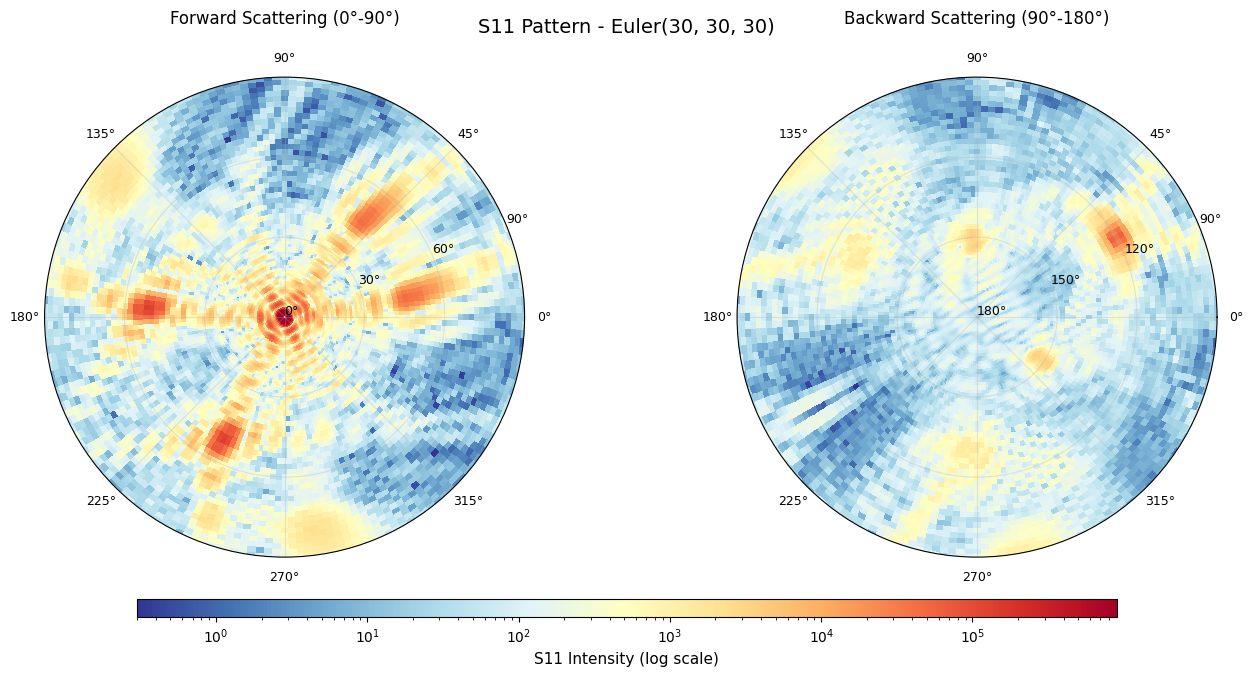

S11 range: 3.02e-01 to 9.00e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 3.02e-01 to 9.00e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


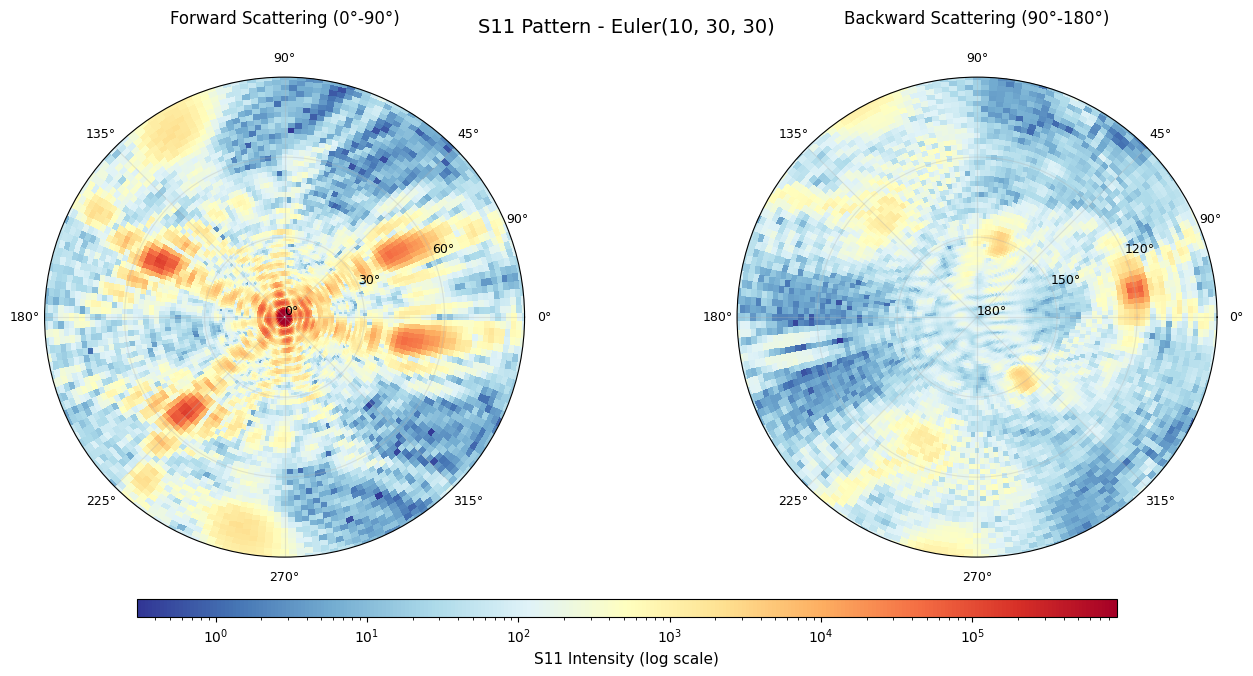

In [95]:
# Comparison 1: Alpha angle variation (30,30,30 vs 10,30,30)
print("=== Comparison 1: Alpha angle variation ===")

alpha_angles = [30, 10]
alpha_problems = []

for alpha in alpha_angles:
    # Create discrete orientation with single Euler angle
    orientation = goad.create_discrete_orientation([goad.Euler(alpha, 30, 30)])

    settings = goad.Settings(
        geom_path=geom_path,
        wavelength=0.532,
        particle_refr_index_re=1.31,
        particle_refr_index_im=0.0,
        medium_refr_index_re=1.0,
        medium_refr_index_im=0.0,
        binning=high_res_binning,
        orientation=orientation,
        beam_power_threshold=0.005,
        cutoff=0.9999,
        max_rec=10,
        max_tir=10,
    )

    mp = goad.MultiProblem(settings)
    print(f"Solving for Euler angles ({alpha}, 30, 30)...")
    mp.py_solve()
    alpha_problems.append((alpha, mp))

# Plot alpha comparison
for alpha, mp in alpha_problems:
    fig, axes = plot_2d_scattering_pattern(
        mp.results, title=f"S11 Pattern - Euler({alpha}, 30, 30)"
    )
    plt.show()

### 5. Compare Multiple Geometries (Optional)


=== Comparison 2: Beta angle variation ===
Solving for Euler angles (30, 10.0, 30)...
Solving for Euler angles (30, 20.0, 30)...
Solving for Euler angles (30, 30.0, 30)...
S11 range: 2.43e-06 to 3.48e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 2.43e-06 to 3.48e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


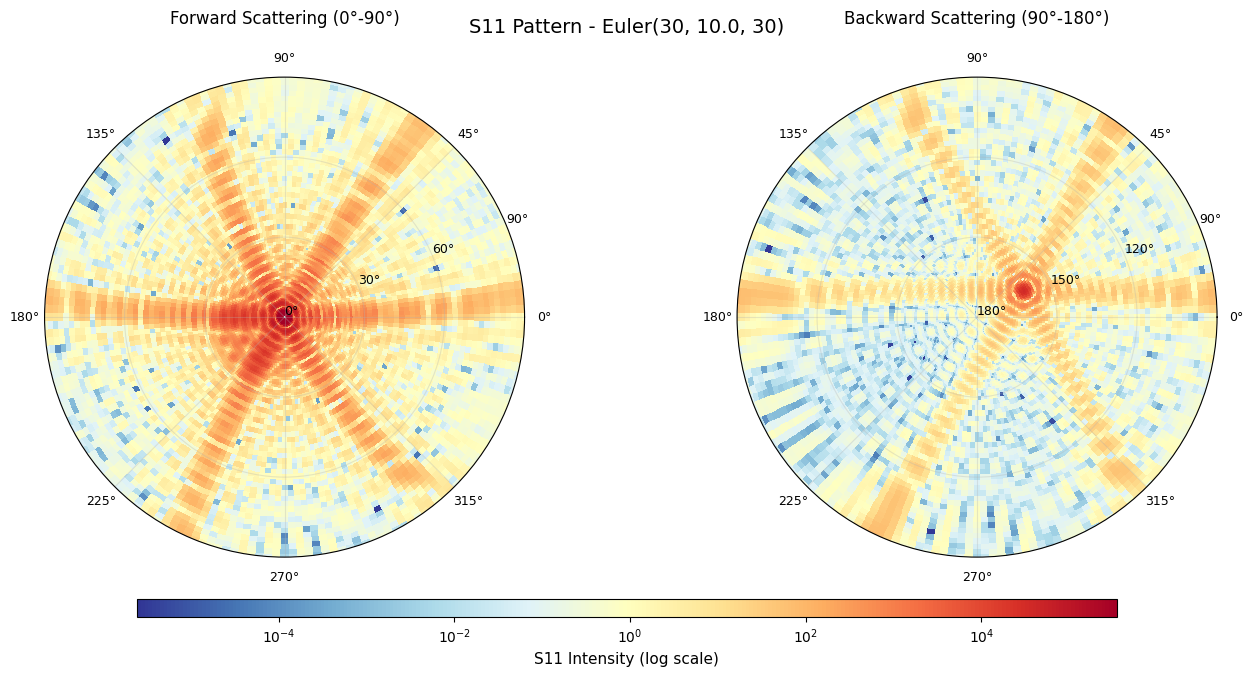

⚠️ Warning: Found 1 NaN values in S11 (0.00% of data)
  NaNs replaced with zeros for visualization
S11 range: 0.00e+00 to 4.51e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 1.00e-10 to 4.51e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


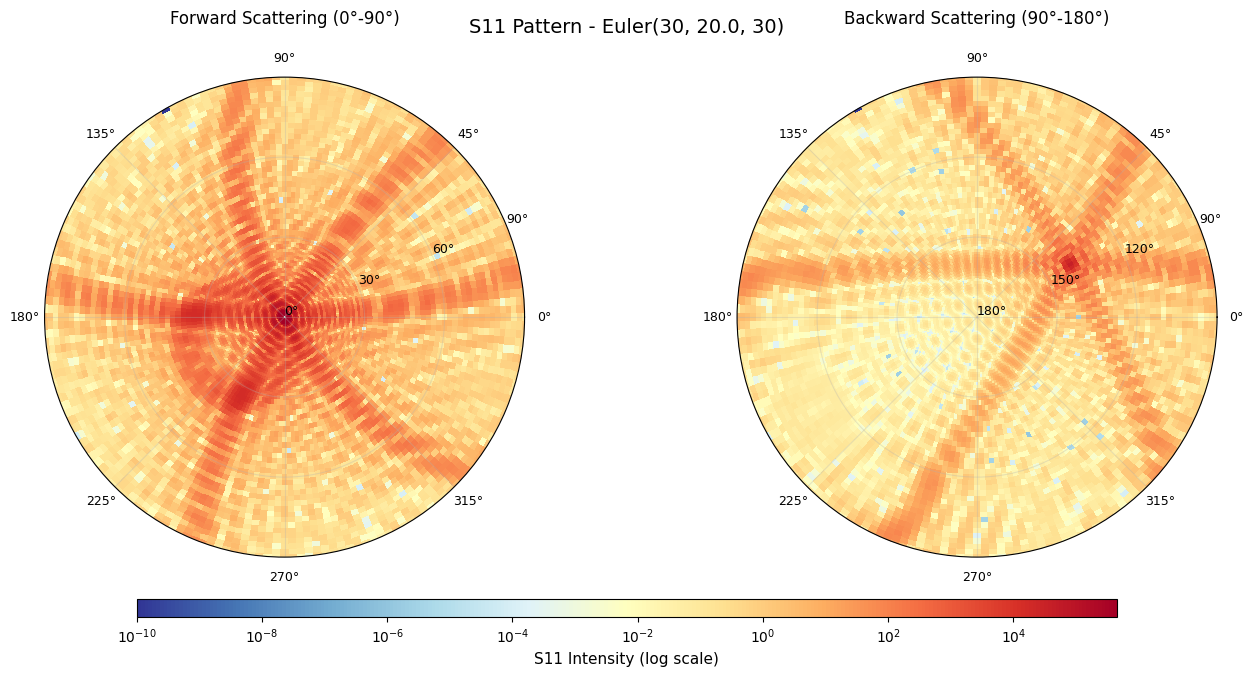

S11 range: 1.59e-07 to 5.23e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 1.59e-07 to 5.23e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


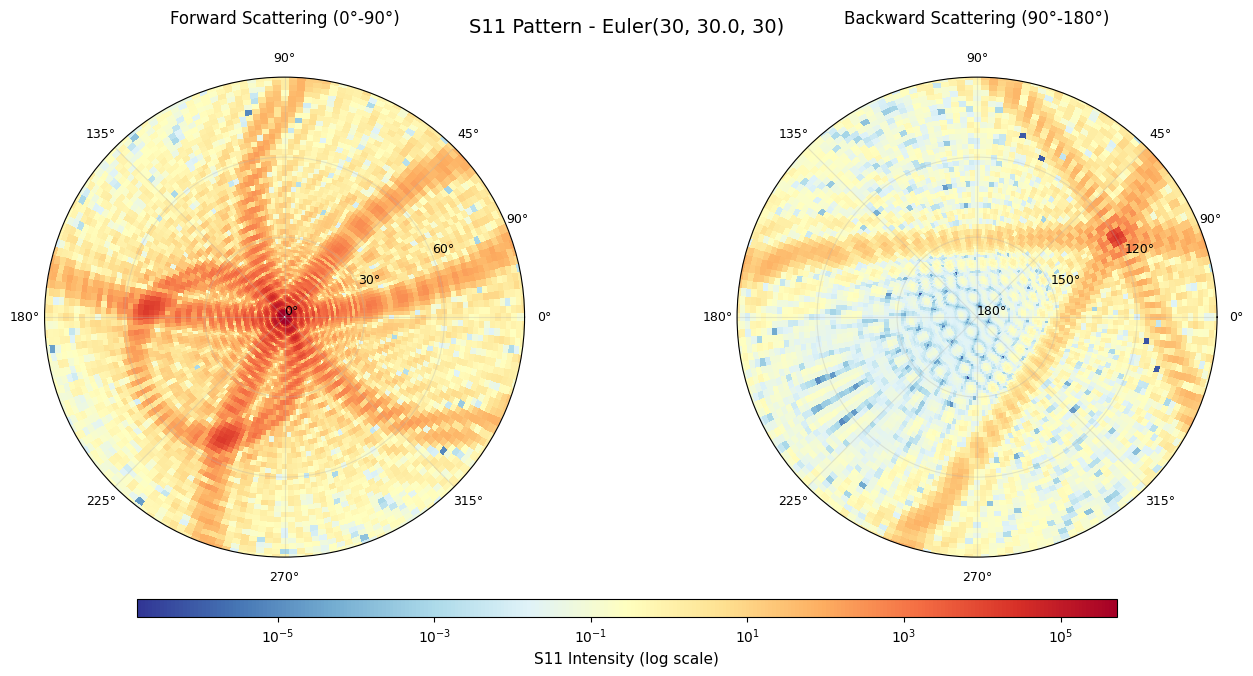

In [96]:
# Comparison 2: Beta angle variation (30,10,30), (30,20,30), (30,30,30)
print("=== Comparison 2: Beta angle variation ===")

beta_angles = [10.0, 20.0, 30.0]
beta_problems = []

for beta in beta_angles:
    # Create discrete orientation with single Euler angle
    orientation = goad.create_discrete_orientation([goad.Euler(30, beta, 30)])

    settings = goad.Settings(
        geom_path=geom_path,
        wavelength=0.532,
        particle_refr_index_re=1.31,
        particle_refr_index_im=0.0,
        medium_refr_index_re=1.0,
        medium_refr_index_im=0.0,
        binning=high_res_binning,
        orientation=orientation,
        beam_power_threshold=0.005,
        cutoff=0.9999,
        max_rec=1,
        max_tir=0,
    )

    mp = goad.MultiProblem(settings)
    print(f"Solving for Euler angles (30, {beta}, 30)...")
    mp.py_solve()
    beta_problems.append((beta, mp))

# Plot beta comparison
for beta, mp in beta_problems:
    fig, axes = plot_2d_scattering_pattern(
        mp.results, title=f"S11 Pattern - Euler(30, {beta}, 30)"
    )
    plt.show()

### 6. Extract Specific Angular Regions


=== Comparison 3: Gamma angle variation ===
Solving for Euler angles (30, 30, 10)...
Solving for Euler angles (30, 30, 20)...
Solving for Euler angles (30, 30, 30)...
S11 range: 4.64e-01 to 8.72e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 4.64e-01 to 8.72e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


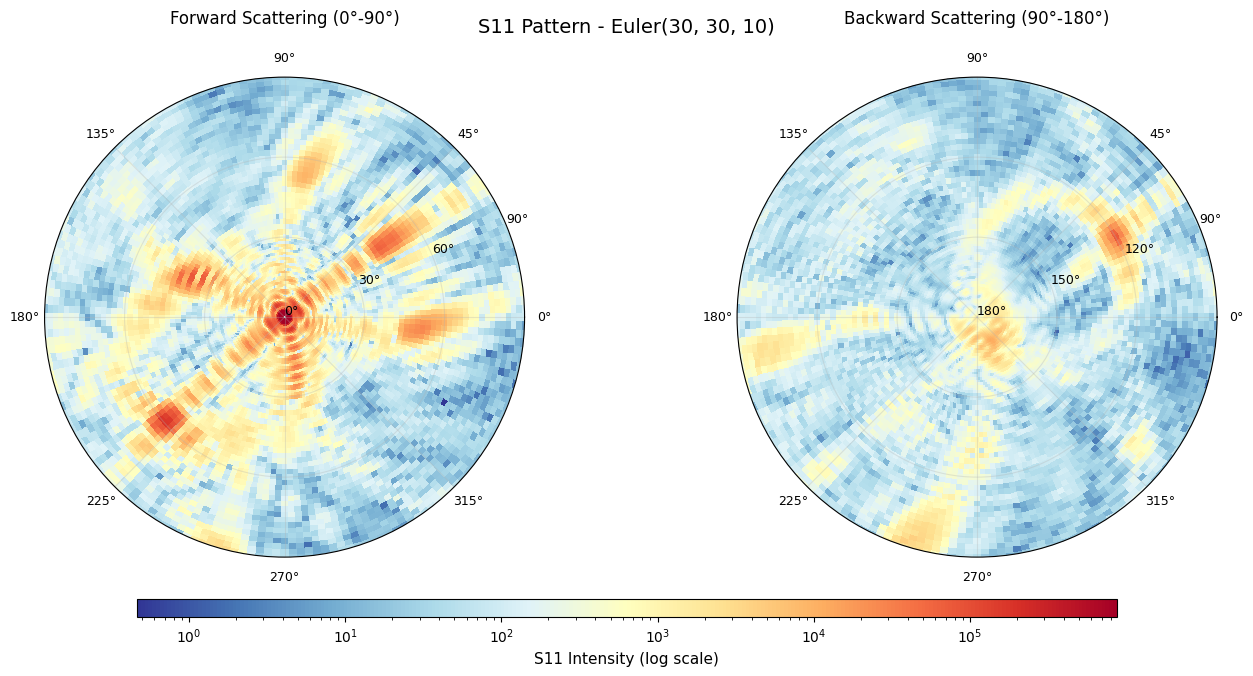

S11 range: 2.32e-01 to 8.67e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 2.32e-01 to 8.67e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


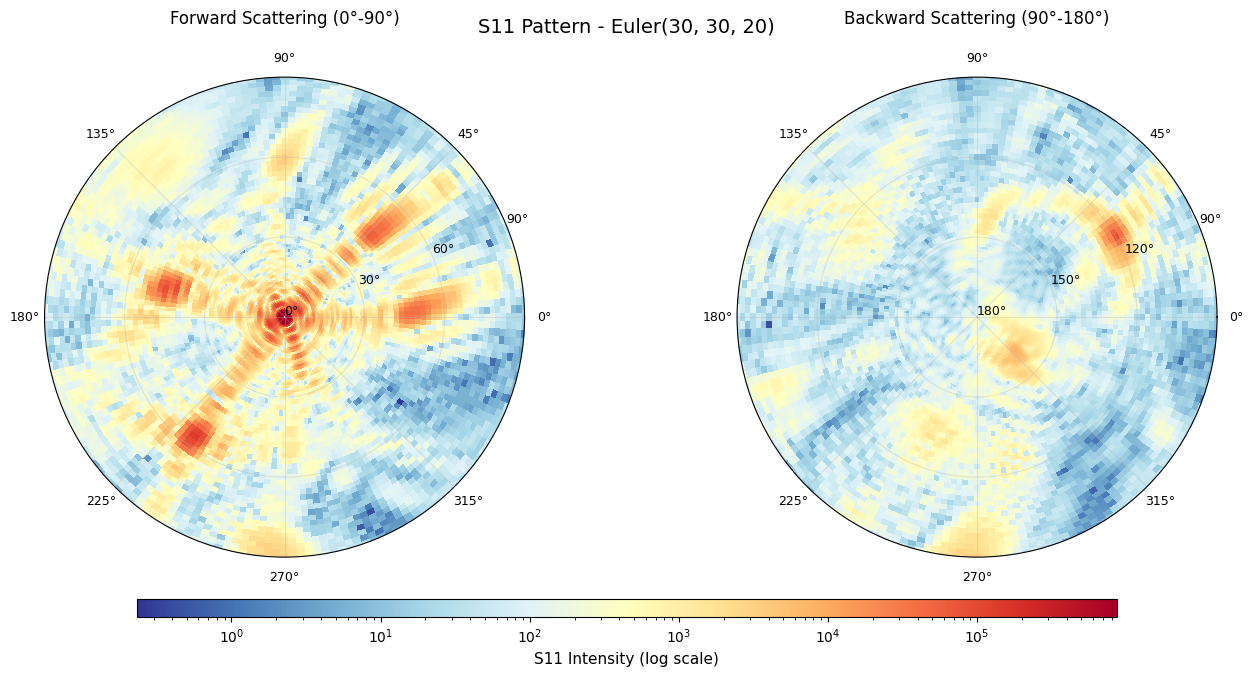

S11 range: 3.00e-01 to 9.00e+06
Number of bins: 25521
Grid: 141 theta × 181 phi bins
Colormap range: 3.00e-01 to 9.00e+05


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_75189/1190238355.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


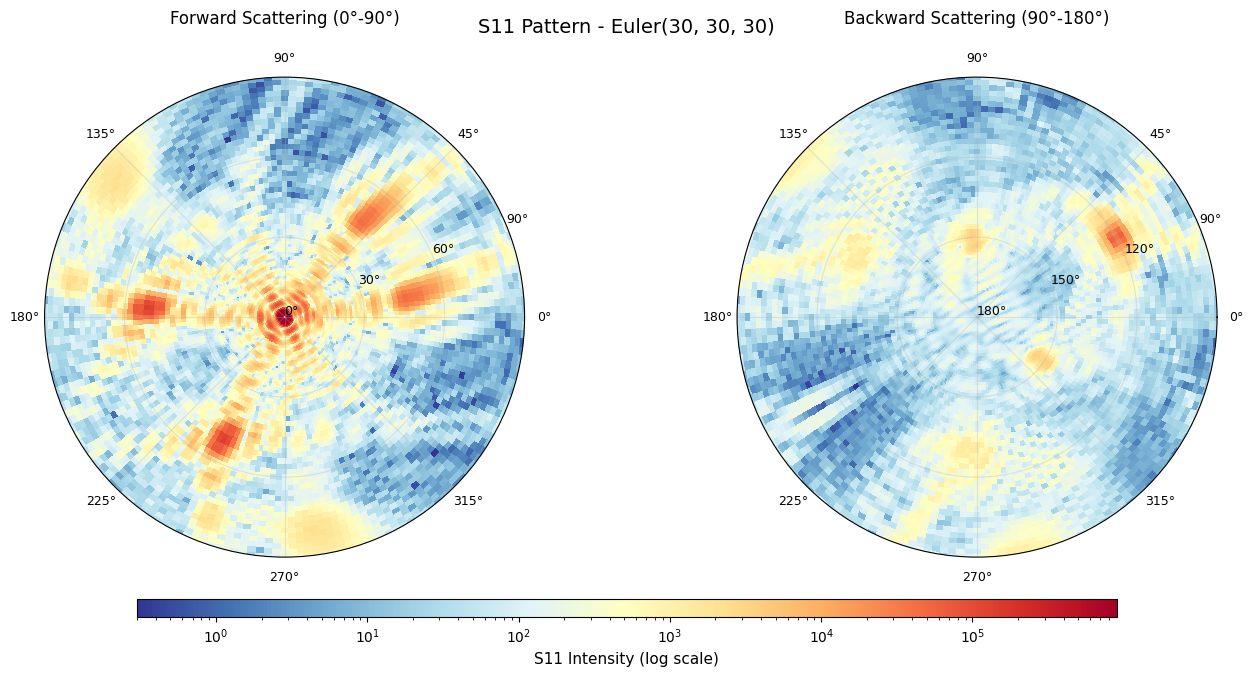


SUMMARY: Integrated Scattering Parameters

Alpha angle variation:
  Euler(30, 30, 30): g=0.838, σ_scat=249.9
  Euler(10, 30, 30): g=0.838, σ_scat=249.9

Beta angle variation:
  Euler(30, 10.0, 30): g=0.963, σ_scat=82.1
  Euler(30, 20.0, 30): g=nan, σ_scat=nan
  Euler(30, 30.0, 30): g=0.965, σ_scat=102.0

Gamma angle variation:
  Euler(30, 30, 10): g=0.819, σ_scat=242.0
  Euler(30, 30, 20): g=0.820, σ_scat=235.5
  Euler(30, 30, 30): g=0.838, σ_scat=249.9


In [97]:
# Comparison 3: Gamma angle variation (30,30,10), (30,30,20), (30,30,30)
print("=== Comparison 3: Gamma angle variation ===")

gamma_angles = [10, 20, 30]
gamma_problems = []

for gamma in gamma_angles:
    # Create discrete orientation with single Euler angle
    orientation = goad.create_discrete_orientation([goad.Euler(30, 30, gamma)])

    settings = goad.Settings(
        geom_path=geom_path,
        wavelength=0.532,
        particle_refr_index_re=1.31,
        particle_refr_index_im=0.0,
        medium_refr_index_re=1.0,
        medium_refr_index_im=0.0,
        binning=high_res_binning,
        orientation=orientation,
        beam_power_threshold=0.005,
        cutoff=0.9999,
        max_rec=10,
        max_tir=10,
    )

    mp = goad.MultiProblem(settings)
    print(f"Solving for Euler angles (30, 30, {gamma})...")
    mp.py_solve()
    gamma_problems.append((gamma, mp))

# Plot gamma comparison
for gamma, mp in gamma_problems:
    fig, axes = plot_2d_scattering_pattern(
        mp.results, title=f"S11 Pattern - Euler(30, 30, {gamma})"
    )
    plt.show()

# Summary comparison of integrated parameters
print("\n" + "=" * 50)
print("SUMMARY: Integrated Scattering Parameters")
print("=" * 50)

print("\nAlpha angle variation:")
for alpha, mp in alpha_problems:
    results = mp.results
    print(
        f"  Euler({alpha}, 30, 30): g={results.asymmetry:.3f}, σ_scat={results.scat_cross:.1f}"
    )

print("\nBeta angle variation:")
for beta, mp in beta_problems:
    results = mp.results
    print(
        f"  Euler(30, {beta}, 30): g={results.asymmetry:.3f}, σ_scat={results.scat_cross:.1f}"
    )

print("\nGamma angle variation:")
for gamma, mp in gamma_problems:
    results = mp.results
    print(
        f"  Euler(30, 30, {gamma}): g={results.asymmetry:.3f}, σ_scat={results.scat_cross:.1f}"
    )